In [3]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [4]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

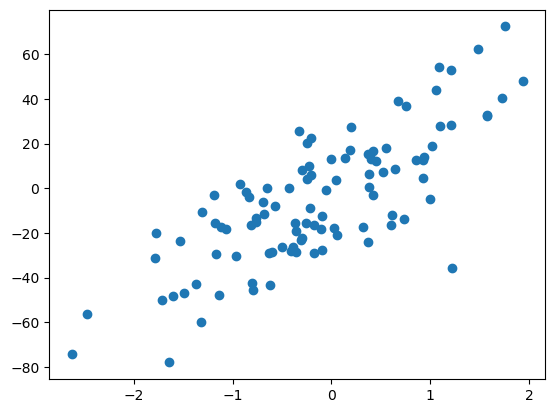

In [5]:
plt.scatter(X,y)

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[25.10750972]
-2.176848140471059


In [22]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4265037325734795

In [9]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

0.3199278945859284

In [16]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_b= -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slope_m= -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.b - (self.lr * loss_slope_m)
            print(self.m,self.b)
    def predict(self,X):
        return self.m*X + self.b
        

In [25]:
gd = GDRegressor(0.001, 50)
gd.fit(X, y)

-111.57998815829856 -94.30106407994052
-57.45176533950326 -79.6634797564922
-53.73595797207554 -66.43850646589648
-43.36276215081877 -55.75453221047578
-36.127105011483245 -46.91703448371773
-29.933174023380047 -39.644529391374114
-24.873299140866266 -33.65317356702174
-20.69812653176993 -28.71847638880729
-17.260495381229312 -24.653866604822504
-14.428775184078901 -21.305968571452727
-12.096409749088178 -18.54839778402164
-10.175298178302798 -16.277064412749585
-8.592933920841396 -14.40623088263389
-7.289584688308985 -12.865277867033742
-6.216052583641335 -11.596038155827346
-5.331814339197345 -10.550601061866622
-4.603492138994365 -9.68950389632272
-4.003593602722105 -8.980242351320213
-3.509474031003476 -8.396043541528732
-3.1024816207540704 -7.914855393425116
-2.7672534058090745 -7.518514233541261
-2.4911353425092395 -7.192059154302207
-2.2637046505763623 -6.9231672764255565
-2.0763763786953797 -6.701688590425128
-1.9220793436396697 -6.519262818624842
-1.7949892104316376 -6.3690038

In [26]:
gd.fit(X_train, y_train)

-1.8936163867955802 -5.7138784098842335
-1.842092672327583 -5.76320642671884
-1.8911142609360465 -5.803467931578514
-1.9197030889660507 -5.838404611020288
-1.9462603891447672 -5.868402852293112
-1.9688116654087886 -5.894206514719123
-1.9882463487867215 -5.916395448881326
-2.004953174735604 -5.9354769960161695
-2.019321115426485 -5.951886180563263
-2.0316767194081584 -5.965997286246686
-2.04230195809189 -5.978132152192791
-2.0514391452376497 -5.9885675483226
-2.0592966833434065 -5.997541482777777
-2.0660537848983203 -6.0052586310967735
-2.071864564465734 -6.011895004302187
-2.076861553019214 -6.01760196333712
-2.08115872077803 -6.022509671270069
-2.08485407660062 -6.026730062025938
-2.0880319033511934 -6.030359393350372
-2.090764680204482 -6.0334804422352875
-2.093114735734894 -6.036164392878332
-2.09513566949294 -6.038472460236429
-2.0968735744920175 -6.040457286203075
-2.098368088487734 -6.04216414025309
-2.0996532980271376 -6.043631951938853
-2.100758515887198 -6.0448941987869915
-2.

In [27]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

-0.1331183017046631